# Appendix 1. UMAP + HDBSCAN hyperparameters

Repeat the notebook 2 run at four settings of the two hyperparameters the result
is most sensitive to: the UMAP neighbourhood size and the HDBSCAN selection
epsilon.  Everything else is held at the notebook 2 values, so a difference
between two runs is a difference those two made.

| input | what it provides |
| --- | --- |
| `metadata/params.csv` | one row per spectrum: the table built in notebook 0; fixes the row order |
| `data/F30_norm.csv` | one column per spectrum: the continuum removed fluxes built in notebook 1 |

| output | |
| --- | --- |
| `results/umap_5100_6450_dim2_nei{12,16,20,24}_eps*.csv` | one file per setting, in the notebook 2 format |

Notebook 3 draws the 16, 20 and 24 embeddings, so **run this before notebook 3**:
0 -> 1 -> 2 -> appendix1 -> 3.


## Imports

In [1]:
import os
import pandas as pd

In [2]:
import hdbscan
import umap

In [3]:
import matplotlib.pyplot as plt

## Configuration


In [4]:
# Input / output locations
PARAMS_PATH = './metadata/params.csv'
SPECTRUM_TABLE_PATH = './data/F30_norm.csv'

RESULTS_DIR = './results'

# Wavelength window handed to UMAP [Angstrom].  It covers the Si II 5972 and
# 6355 features, the part of the spectrum the classification rests on, and is
# narrower than the 5000-7000 grid the spectrum table is sampled on.
WINDOW_MIN_AA = 5100
WINDOW_MAX_AA = 6450

# Column label format written by notebook 1: '<SN name>%%%<SN type>$$$<phase>'
NAME_TYPE_SEPARATOR = '%%%'

In [5]:
# The settings this notebook varies: (UMAP n_neighbors, HDBSCAN epsilon).  The
# first is the setting of notebook 2; a larger neighbourhood asks UMAP to keep
# more of the global structure, which loosens the groups it draws, so epsilon
# follows it down to keep the leaves from being merged back together.
RUNS = [
    (12, 0.475),
    (16, 0.450),
    (20, 0.380),
    (24, 0.410),
]

In [6]:
# UMAP, held fixed.  `min_dist = 0` packs each group as tightly as UMAP allows,
# which is what HDBSCAN wants to see; `random_state` fixes the layout across runs.
UMAP_N_COMPONENTS = 2
UMAP_MIN_DIST = 0.0
UMAP_METRIC = 'euclidean'
UMAP_RANDOM_STATE = 50

# HDBSCAN, held fixed.  `leaf` selection keeps the small subtypes apart instead
# of merging them into their parent cluster; the epsilon varied above then sets
# how close two leaves have to be before they are joined again.
HDBSCAN_MIN_CLUSTER_SIZE = 2
HDBSCAN_CLUSTER_SELECTION_METHOD = 'leaf'

# Columns appended to params.csv
EMBEDDING_COLUMNS = ['umap_x', 'umap_y']
LABEL_COLUMN = 'DB_label'

# HDBSCAN marks a point it leaves out of every cluster with this label
NOISE_LABEL = -1

# Column order of the composition table; any subtype not listed is appended
SN_TYPE_ORDER = ['NV', 'HV', '91T', '91bg', 'Iax', '00cx']

In [7]:
def results_path(n_neighbors, epsilon, results_dir=RESULTS_DIR):
    """Where the run at these settings is written.

    The settings name the file, in the format of notebook 2: the epsilon drops
    its decimal point (0.475 -> 0475), the convention the earlier result files
    were named by, at the three decimals the runs here are set to.
    """
    epsilon_tag = f'{epsilon:.3f}'.replace('.', '')

    return (f'{results_dir}/umap_{WINDOW_MIN_AA}_{WINDOW_MAX_AA}'
            f'_dim{UMAP_N_COMPONENTS}_nei{n_neighbors}_eps{epsilon_tag}.csv')


[results_path(n_neighbors, epsilon) for n_neighbors, epsilon in RUNS]

['./results/umap_5100_6450_dim2_nei12_eps0475.csv',
 './results/umap_5100_6450_dim2_nei16_eps0450.csv',
 './results/umap_5100_6450_dim2_nei20_eps0380.csv',
 './results/umap_5100_6450_dim2_nei24_eps0410.csv']

## Reading the inputs


In [8]:
def load_params(params_path=PARAMS_PATH):
    """Read the metadata table built in notebook 0.

    Its row order becomes the row order of the results table.
    """
    return pd.read_csv(params_path)

In [9]:
def load_fluxes(params, spectrum_path=SPECTRUM_TABLE_PATH,
                window_min=WINDOW_MIN_AA, window_max=WINDOW_MAX_AA):
    """Read the normalized spectrum table of notebook 1 as one row per supernova.

    The table holds one column per spectrum, labelled
    `<SN name>%%%<SN type>$$$<phase>`, and one row per wavelength bin.  It is cut
    to the window given, transposed so that each supernova becomes a row and each
    wavelength a feature, and reordered to follow the rows of `params` so that the
    embedding can be written straight back next to the metadata.
    """
    spectra = pd.read_csv(spectrum_path).set_index('AA')
    spectra = spectra[(spectra.index > window_min) & (spectra.index < window_max)]

    column_of = {column.split(NAME_TYPE_SEPARATOR)[0]: column for column in spectra.columns}
    if len(column_of) != len(spectra.columns):
        raise ValueError('the spectrum table holds more than one spectrum per supernova')

    # A missing supernova raises a KeyError naming it
    ordered = spectra[[column_of[name] for name in params['SN_name']]]

    return ordered.T.reset_index(drop=True)

## Embedding and clustering


In [10]:
def embed(fluxes, n_neighbors, n_components=UMAP_N_COMPONENTS,
          min_dist=UMAP_MIN_DIST, metric=UMAP_METRIC, random_state=UMAP_RANDOM_STATE):
    """UMAP embedding of the fluxes, one row per supernova."""
    reducer = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors,
                        min_dist=min_dist, metric=metric, random_state=random_state)

    return reducer.fit_transform(fluxes)

In [11]:
def cluster(embedding, cluster_selection_epsilon,
            min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
            cluster_selection_method=HDBSCAN_CLUSTER_SELECTION_METHOD):
    """HDBSCAN label of every embedded spectrum; -1 is a spectrum left unclustered."""
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        cluster_selection_epsilon=cluster_selection_epsilon,
        cluster_selection_method=cluster_selection_method,
    ).fit(embedding)

    return clusterer.labels_

## Run


In [12]:
params = load_params()
fluxes = load_fluxes(params)
print(f'{len(fluxes)} spectra x {fluxes.shape[1]} wavelength bins '
      f'({WINDOW_MIN_AA}-{WINDOW_MAX_AA} A)')

119 spectra x 675 wavelength bins (5100-6450 A)


In [13]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# One results table per setting, keyed by it, for the tables below to read
results_of_run = {}

for n_neighbors, epsilon in RUNS:
    embedding = embed(fluxes, n_neighbors)
    labels = cluster(embedding, epsilon)

    results = params.copy()
    results[EMBEDDING_COLUMNS] = embedding
    results[LABEL_COLUMN] = labels

    path = results_path(n_neighbors, epsilon)
    results.to_csv(path, index=False)
    results_of_run[(n_neighbors, epsilon)] = results

    n_clusters = len(set(labels) - {NOISE_LABEL})
    n_noise = int((labels == NOISE_LABEL).sum())
    print(f'n_neighbors={n_neighbors:2d}  epsilon={epsilon:.3f}  '
          f'{n_clusters} clusters, {n_noise} unclustered  ->  {path}')

n_neighbors=12  epsilon=0.475  6 clusters, 4 unclustered  ->  ./results/umap_5100_6450_dim2_nei12_eps0475.csv
n_neighbors=16  epsilon=0.450  5 clusters, 1 unclustered  ->  ./results/umap_5100_6450_dim2_nei16_eps0450.csv
n_neighbors=20  epsilon=0.380  7 clusters, 10 unclustered  ->  ./results/umap_5100_6450_dim2_nei20_eps0380.csv
n_neighbors=24  epsilon=0.410  5 clusters, 6 unclustered  ->  ./results/umap_5100_6450_dim2_nei24_eps0410.csv


## Table 1: what each setting found

Per run: the number of clusters, how many spectra were left out of all of them,
and the largest and smallest cluster size.


In [14]:
def summarize(results, n_neighbors, epsilon, label_column=LABEL_COLUMN):
    """One row of table 1: the cluster count and sizes this run produced."""
    labels = results[label_column]
    sizes = labels[labels != NOISE_LABEL].value_counts()

    return {
        'n_neighbors': n_neighbors,
        'epsilon': epsilon,
        'N': len(results),
        'clusters': len(sizes),
        'clustered': int(sizes.sum()),
        'unclustered': int((labels == NOISE_LABEL).sum()),
        'largest': int(sizes.max()),
        'smallest': int(sizes.min()),
    }


summary = pd.DataFrame([summarize(results, *run) for run, results in results_of_run.items()])
summary

,n_neighbors,epsilon,N,clusters,clustered,unclustered,largest,smallest
0,12,0.475,119,6,115,4,34,6
1,16,0.450,119,5,118,1,41,4
2,20,0.380,119,7,109,10,28,5
3,24,0.410,119,5,113,6,44,2


## Table 2: how the subtypes fall across the clusters

One row per cluster of every run.  The HDBSCAN labels are arbitrary and change
from run to run, so what carries over between settings is which subtypes are held
together and which are separated, not the number a cluster is called.  The
unclustered spectra are kept as a row marked `-1`.


In [15]:
def compose(results, n_neighbors, epsilon,
            label_column=LABEL_COLUMN, type_order=SN_TYPE_ORDER):
    """The cluster x subtype counts of one run, as the rows of table 2."""
    counts = pd.crosstab(results[label_column], results['SN_type'])
    counts.columns.name = None

    # The fixed column order, with any subtype not listed appended
    columns = [t for t in type_order if t in counts] + [t for t in counts if t not in type_order]
    counts = counts[columns]

    counts.insert(0, 'N', counts.sum(axis=1))
    counts = counts.rename_axis('cluster').reset_index()
    counts.insert(0, 'epsilon', epsilon)
    counts.insert(0, 'n_neighbors', n_neighbors)

    return counts


composition = pd.concat([compose(results, *run) for run, results in results_of_run.items()],
                        ignore_index=True).fillna(0)

## Check


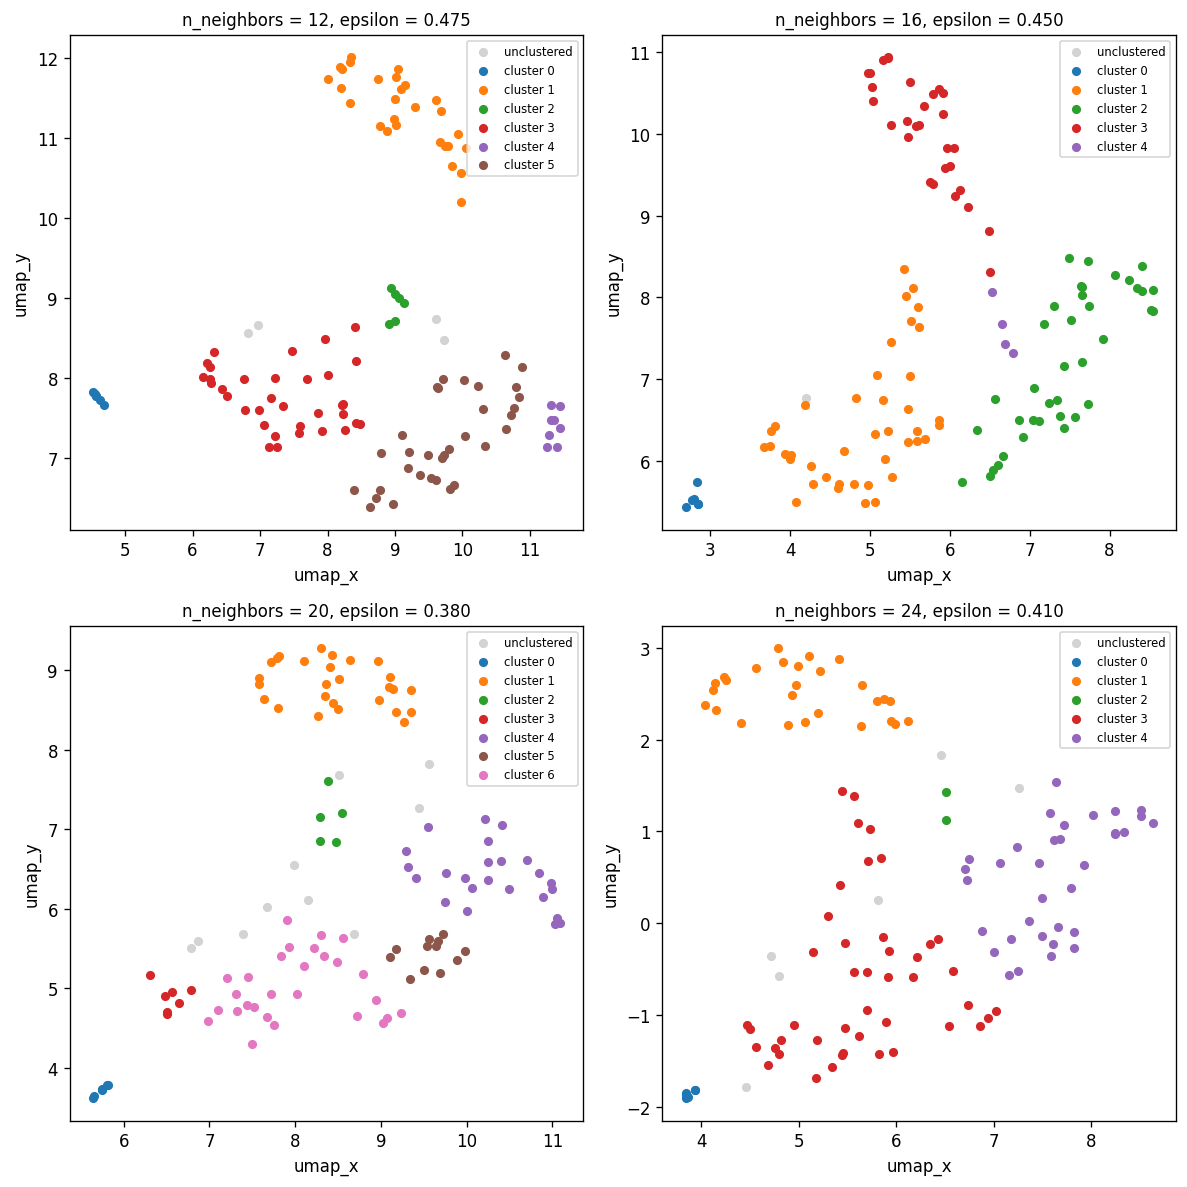

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=120)

for ax, ((n_neighbors, epsilon), results) in zip(axes.ravel(), results_of_run.items()):
    labels = results[LABEL_COLUMN]

    for label in sorted(set(labels)):
        in_cluster = labels == label
        name = 'unclustered' if label == NOISE_LABEL else f'cluster {label}'
        ax.scatter(results['umap_x'][in_cluster], results['umap_y'][in_cluster], s=20,
                   label=name, color='lightgrey' if label == NOISE_LABEL else None)

    ax.set_title(f'n_neighbors = {n_neighbors}, epsilon = {epsilon:.3f}', fontsize=10)
    ax.set_xlabel('umap_x')
    ax.set_ylabel('umap_y')
    ax.legend(loc='best', fontsize=7)

fig.tight_layout()
plt.show()